In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import wandb

api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/jack/.netrc.


In [2]:
runs = api.runs("structure")

def parse_run_name(name):
    match = re.match(r'v2-d(\d+)-w(\w+)-(\d+e[+\-]?\d+)', name)
    if match:
        return int(match.group(1)), match.group(2), float(match.group(3))
    return None

parsed_runs = []
for run in runs:
    parsed = parse_run_name(run.name)
    if parsed:
        num_layers, window_type, max_flops = parsed
        parsed_runs.append((run, num_layers, window_type, max_flops))

print(f"Found {len(parsed_runs)} v2 runs with valid names")

Found 25 v2 runs with valid names


In [3]:
def compute_params(num_layers):
    """Compute non-embedding params from num_layers (hidden_dim = num_layers * 64)."""
    D = num_layers * 64
    V = 50304
    N = max(1, (D + 127) // 128)
    K = N
    H = 128
    I = ((4 * D + 63) // 64) * 64
    embed_params = D * V
    layer_params = (D * N * H) + 2 * (D * K * H) + (N * H * D) + 2 * (D * I) + 4 * D
    total_params = embed_params + num_layers * layer_params + D + (D * V)
    return total_params - embed_params

def get_final_loss(run):
    if run.state != "finished":
        return None, f"state={run.state}"
    history = run.history(keys=["val/loss"])
    losses = history["val/loss"].dropna().values
    if len(losses) == 0:
        return None, "no val/loss values"
    return losses[-1], None

results = {}
skipped = []

for run, num_layers, window_type, max_flops in parsed_runs:
    final_loss, reason = get_final_loss(run)
    if final_loss is None:
        skipped.append((run.name, reason))
    else:
        params = compute_params(num_layers)
        results[run.name] = (params, final_loss, max_flops, window_type)

print(f"Collected {len(results)} runs")
if skipped:
    print(f"\nSkipped {len(skipped)} runs:")
    for name, reason in skipped:
        print(f"  {name}: {reason}")

Collected 22 runs

Skipped 3 runs:
  v2-d8-wfull-3e+18: state=crashed
  v2-d10-wfull-3e+18: state=crashed
  v2-d8-wfull-6e+18: state=running


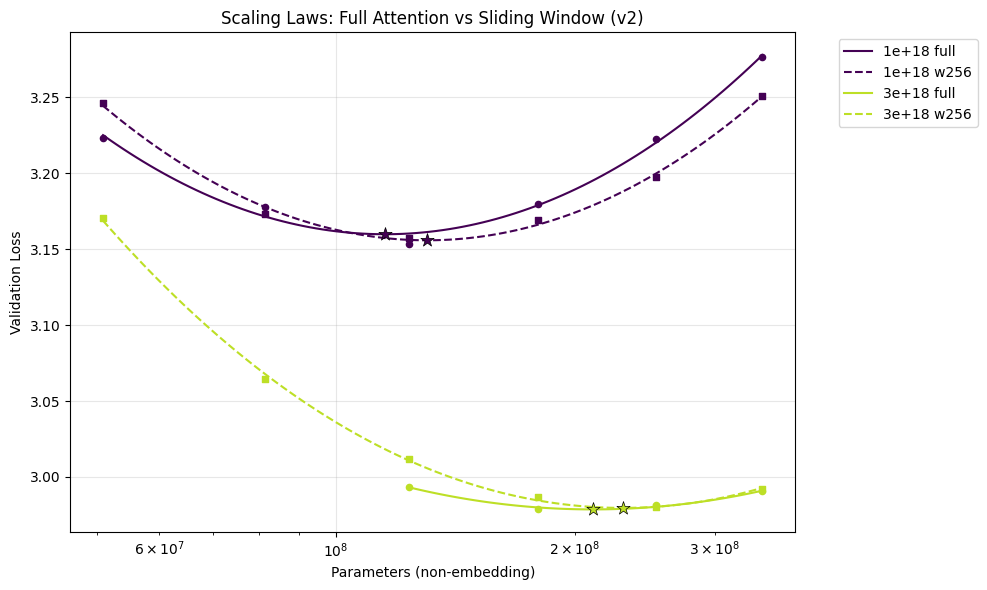

In [4]:
flops_values = sorted(set(r[2] for r in results.values()))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(flops_values)))
color_map = dict(zip(flops_values, colors))

plt.figure(figsize=(10, 6))

for max_flops in flops_values:
    for window_type, linestyle, marker in [("full", "-", "o"), ("256", "--", "s")]:
        points = [(params, loss) for params, loss, flops, wt in results.values() if flops == max_flops and wt == window_type]
        if len(points) < 3:
            continue
        points.sort()
        params_vals, loss_vals = zip(*points)
        params_arr, loss_arr = np.array(params_vals), np.array(loss_vals)
        
        # Quadratic fit in log-log space
        log_params, log_loss = np.log(params_arr), np.log(loss_arr)
        coeffs = np.polyfit(log_params, log_loss, 2)
        
        # Smooth curve
        log_params_smooth = np.linspace(log_params.min(), log_params.max(), 100)
        log_loss_smooth = np.polyval(coeffs, log_params_smooth)
        
        label = f"{max_flops:.0e}" + (" w256" if window_type == "256" else " full")
        plt.plot(np.exp(log_params_smooth), np.exp(log_loss_smooth), linestyle, color=color_map[max_flops], label=label)
        plt.scatter(params_arr, loss_arr, color=color_map[max_flops], s=20, marker=marker, zorder=5)
        
        # Mark minimum of fitted curve (if within data range)
        a, b, c = coeffs
        if a > 0:  # parabola opens upward
            log_params_min = -b / (2 * a)
            if log_params.min() <= log_params_min <= log_params.max():
                log_loss_min = np.polyval(coeffs, log_params_min)
                plt.scatter([np.exp(log_params_min)], [np.exp(log_loss_min)], color=color_map[max_flops], 
                           s=100, marker="*", edgecolors="black", linewidths=0.5, zorder=10)

plt.xscale("log")
plt.xlabel("Parameters (non-embedding)")
plt.ylabel("Validation Loss")
plt.title("Scaling Laws: Full Attention vs Sliding Window (v2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()